In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import probplot
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, 
import shap
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import  StandardScaler
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer, PowerTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel
from feature_engine.outliers import Winsorizer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from catboost import CatBoostRegressor

### Reading data

In [2]:
data = pd.read_csv("D:\IS217\DoAnCK\Superstore_preprocessed.csv",sep='\t', encoding='cp1252')
data

,RowID,OrderID,OrderDate,ShipDate,ShipMode,CustomerID,CustomerName,Segment,City,State,...,SubCategory,ProductName,Sales,Quantity,Discount,Profit,IsHoliday,IsWeekend,HolidayScore,DaysToShip
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0,1,1,3
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0,1,1,3
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,Los Angeles,California,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0,0,0,4
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,0,0,0,7
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0,0,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2011-110422,2011-01-22,2011-01-24,Second Class,TB-21400,Tom Boeckenhauer,Consumer,Miami,Florida,...,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,0,1,1,2
9990,9991,CA-2014-121258,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,Costa Mesa,California,...,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,0,0,0,5
9991,9992,CA-2014-121258,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,Costa Mesa,California,...,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,0,0,0,5
9992,9993,CA-2014-121258,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,Costa Mesa,California,...,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,0,0,0,5


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   RowID         9994 non-null   int64  
 1   OrderID       9994 non-null   object 
 2   OrderDate     9994 non-null   object 
 3   ShipDate      9994 non-null   object 
 4   ShipMode      9994 non-null   object 
 5   CustomerID    9994 non-null   object 
 6   CustomerName  9994 non-null   object 
 7   Segment       9994 non-null   object 
 8   City          9994 non-null   object 
 9   State         9994 non-null   object 
 10  PostalCode    9994 non-null   int64  
 11  Region        9994 non-null   object 
 12  ProductID     9994 non-null   object 
 13  Category      9994 non-null   object 
 14  SubCategory   9994 non-null   object 
 15  ProductName   9994 non-null   object 
 16  Sales         9994 non-null   float64
 17  Quantity      9994 non-null   int64  
 18  Discount      9994 non-null 

### Preprocessing data

#### Feature extraction

In [4]:
data['Profit Margin'] = data['Profit']/data['Sales']
data['Discounted Profit'] = data['Profit']-data['Profit']*data['Discount']
data['Discount Percentage'] = data['Discount']/data['Sales']*100
data['Operating Expenses'] = data['Sales'] - data['Profit']
data['Net Profit'] = data['Profit'] - data['Discount']
data['OrderDate'] = pd.to_datetime(data['OrderDate'],errors='coerce')
data['ShipDate'] = pd.to_datetime(data['ShipDate'],errors='coerce')

data['OrderYear'] = data['OrderDate'].dt.year
data['OrderMonth'] = data['OrderDate'].dt.month
data['OrderDay'] = data['OrderDate'].dt.day
data['OrderWeekday'] = data['OrderDate'].dt.dayofweek
data['ShipYear'] = data['ShipDate'].dt.year
data['ShipMonth'] = data['ShipDate'].dt.month
data['ShipDay'] = data['ShipDate'].dt.day
data['ShipWeekday'] = data['ShipDate'].dt.dayofweek
data.drop(['OrderDate','ShipDate'],axis=1,inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   RowID                9994 non-null   int64  
 1   OrderID              9994 non-null   object 
 2   ShipMode             9994 non-null   object 
 3   CustomerID           9994 non-null   object 
 4   CustomerName         9994 non-null   object 
 5   Segment              9994 non-null   object 
 6   City                 9994 non-null   object 
 7   State                9994 non-null   object 
 8   PostalCode           9994 non-null   int64  
 9   Region               9994 non-null   object 
 10  ProductID            9994 non-null   object 
 11  Category             9994 non-null   object 
 12  SubCategory          9994 non-null   object 
 13  ProductName          9994 non-null   object 
 14  Sales                9994 non-null   float64
 15  Quantity             9994 non-null   i

In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
RowID,9994.0,4997.500000,2885.163629,1.0000,2499.250000,4997.500000,7495.750000,9994.00000
PostalCode,9994.0,55190.379428,32063.693350,1040.0000,23223.000000,56430.500000,90008.000000,99301.00000
Sales,9994.0,229.858001,623.245101,0.4440,17.280000,54.490000,209.940000,22638.48000
Quantity,9994.0,3.789574,2.225110,1.0000,2.000000,3.000000,5.000000,14.00000
Discount,9994.0,0.156203,0.206452,0.0000,0.000000,0.200000,0.200000,0.80000
Profit,9994.0,28.656896,234.260108,-6599.9780,1.728750,8.666500,29.364000,8399.97600
IsHoliday,9994.0,0.041925,0.200428,0.0000,0.000000,0.000000,0.000000,1.00000
IsWeekend,9994.0,0.115970,0.320204,0.0000,0.000000,0.000000,0.000000,1.00000
HolidayScore,9994.0,0.157895,0.365209,0.0000,0.000000,0.000000,0.000000,2.00000
DaysToShip,9994.0,3.958875,1.747097,0.0000,3.000000,4.000000,5.000000,7.00000


#### Encoding data

In [6]:
def onehotencode(data: pd.DataFrame,col: str) -> pd.DataFrame:
    encoder = OneHotEncoder(drop='first',sparse_output=False,max_categories=10)
    encoded_data = encoder.fit_transform(data[[col]])
    encoded_data = pd.DataFrame(encoded_data,columns=encoder.get_feature_names_out())
    return encoded_data

In [7]:
for col in ['ShipMode','Segment','State','City','Region','Category','SubCategory','ProductName']:
    encoded_data = onehotencode(data,col)
    data = pd.concat([data,encoded_data],axis=1)
    data.drop(col,axis=1,inplace=True)

In [8]:
data.columns

Index(['RowID', 'OrderID', 'CustomerID', 'CustomerName', 'PostalCode',
       'ProductID', 'Sales', 'Quantity', 'Discount', 'Profit', 'IsHoliday',
       'IsWeekend', 'HolidayScore', 'DaysToShip', 'Profit Margin',
       'Discounted Profit', 'Discount Percentage', 'Operating Expenses',
       'Net Profit', 'OrderYear', 'OrderMonth', 'OrderDay', 'OrderWeekday',
       'ShipYear', 'ShipMonth', 'ShipDay', 'ShipWeekday', 'ShipMode_Same Day',
       'ShipMode_Second Class', 'ShipMode_Standard Class', 'Segment_Corporate',
       'Segment_Home Office', 'State_Florida', 'State_Illinois',
       'State_Michigan', 'State_New York', 'State_Ohio', 'State_Pennsylvania',
       'State_Texas', 'State_Washington', 'State_infrequent_sklearn',
       'City_Columbus', 'City_Houston', 'City_Los Angeles',
       'City_New York City', 'City_Philadelphia', 'City_San Diego',
       'City_San Francisco', 'City_Seattle', 'City_infrequent_sklearn',
       'Region_East', 'Region_South', 'Region_West',
       'Cat

##### Feature Transformation

In [9]:
skewed_cols = ['Quantity',
 'Discount',
 'Profit',
 'Profit Margin',
 'Discounted Profit',
 'Discount Percentage',
 'Operating Expenses',
 'Net Profit',
 'OrderDay',
 'OrderWeekday',
 'OrderMonth',
 'ShipDay']

Skewness of Quantity: 1.2785447527223421
Kurtosis of Quantity: 1.9918893664821322


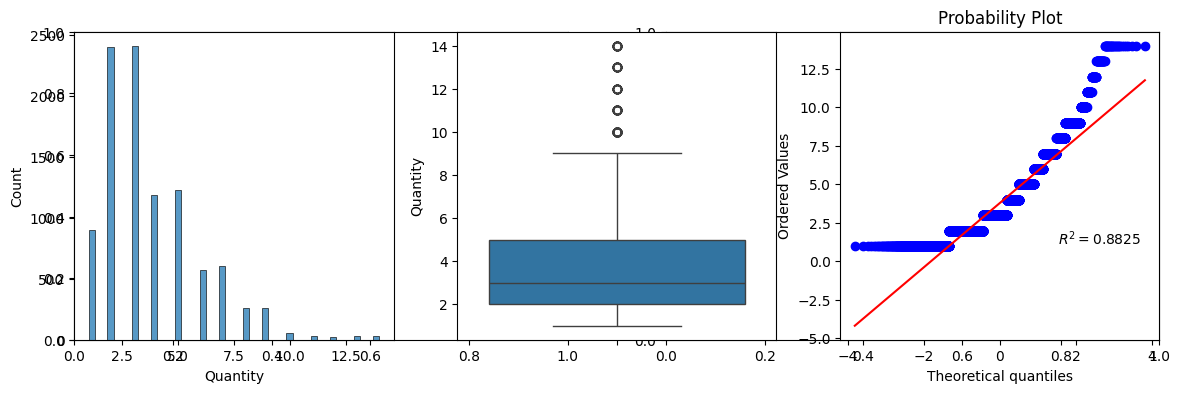

Skewness of Discount: 1.6842947474238648
Kurtosis of Discount: 2.4095461225966774


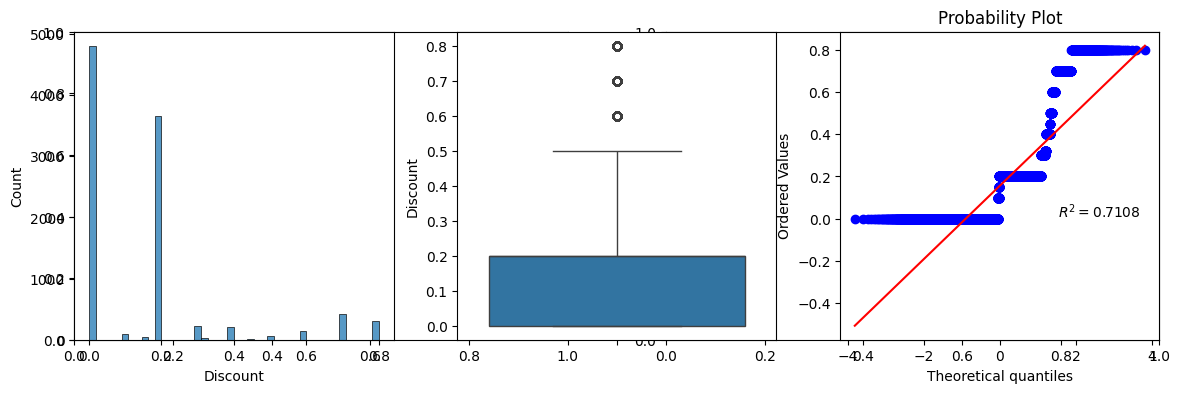

Skewness of Profit: 7.561431562468343
Kurtosis of Profit: 397.1885145524141


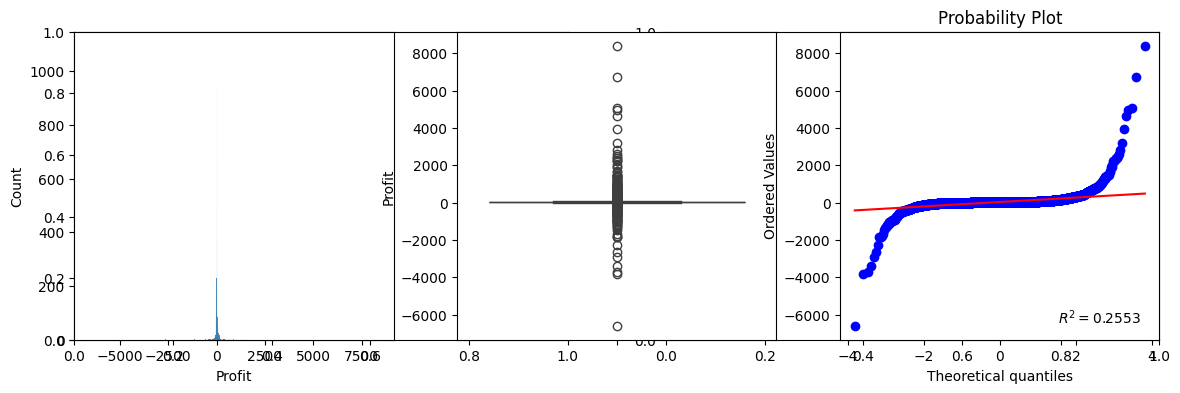

Skewness of Profit Margin: -2.8948263069055997
Kurtosis of Profit Margin: 10.173344306792593


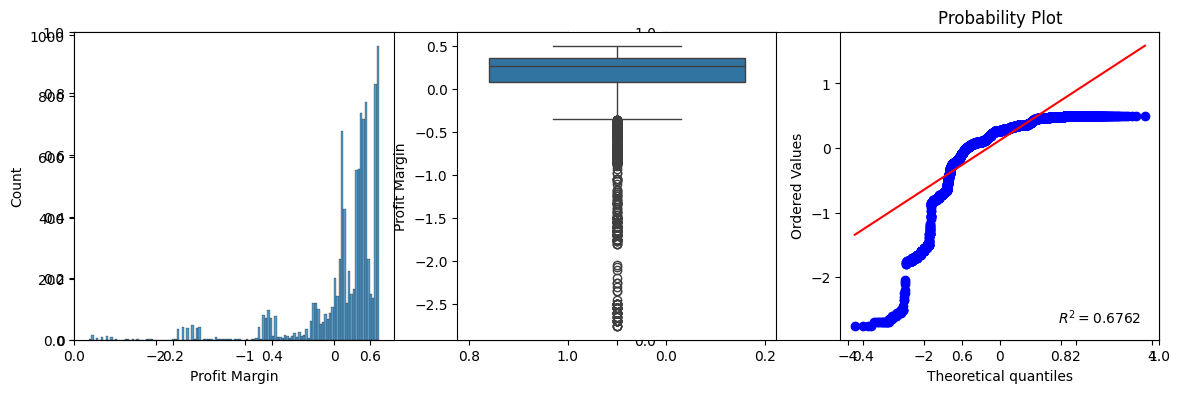

Skewness of Discounted Profit: 19.357489966004742
Kurtosis of Discounted Profit: 617.6946571438322


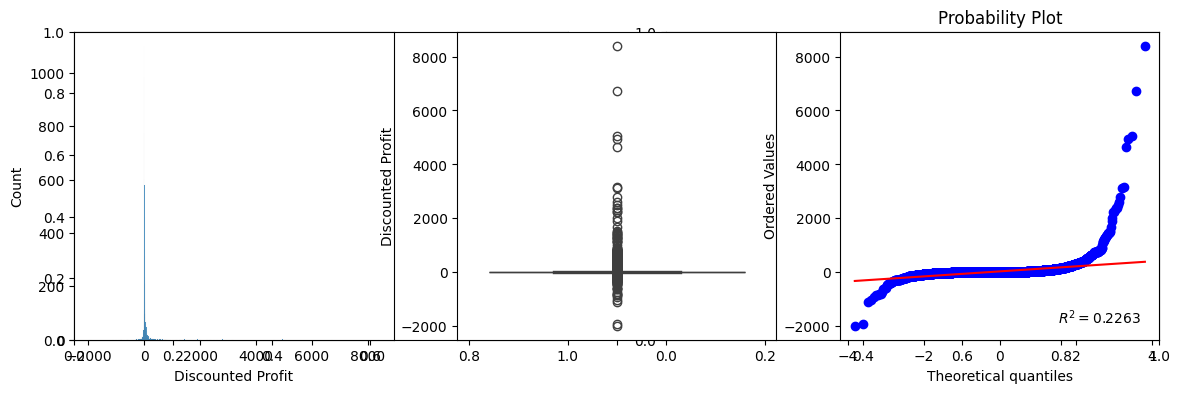

Skewness of Discount Percentage: 10.828681062923055
Kurtosis of Discount Percentage: 188.87754320504303


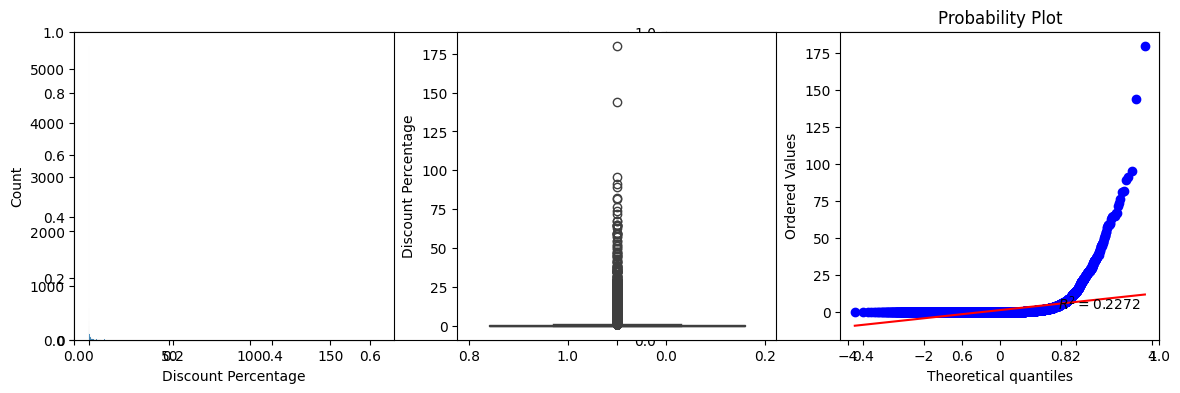

Skewness of Operating Expenses: 14.753072381068696
Kurtosis of Operating Expenses: 454.59220671349067


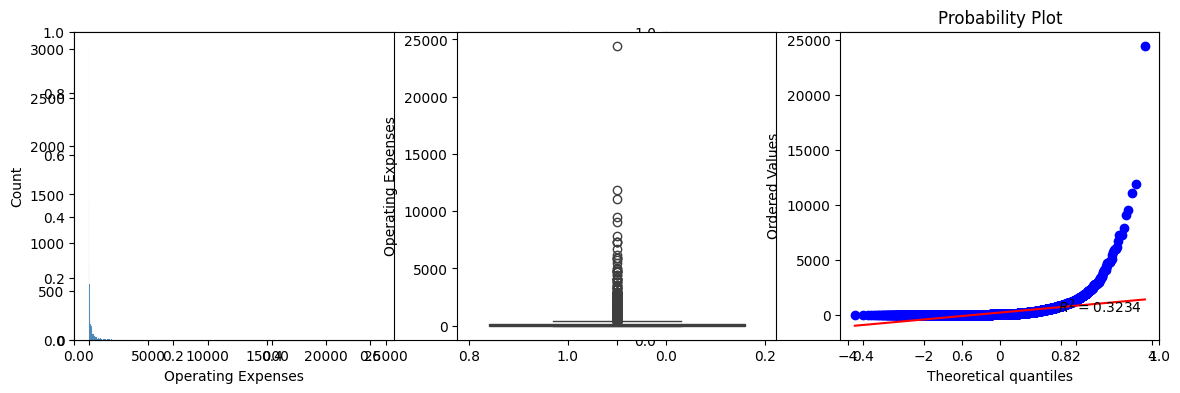

Skewness of Net Profit: 7.556164262685539
Kurtosis of Net Profit: 396.94728055620953


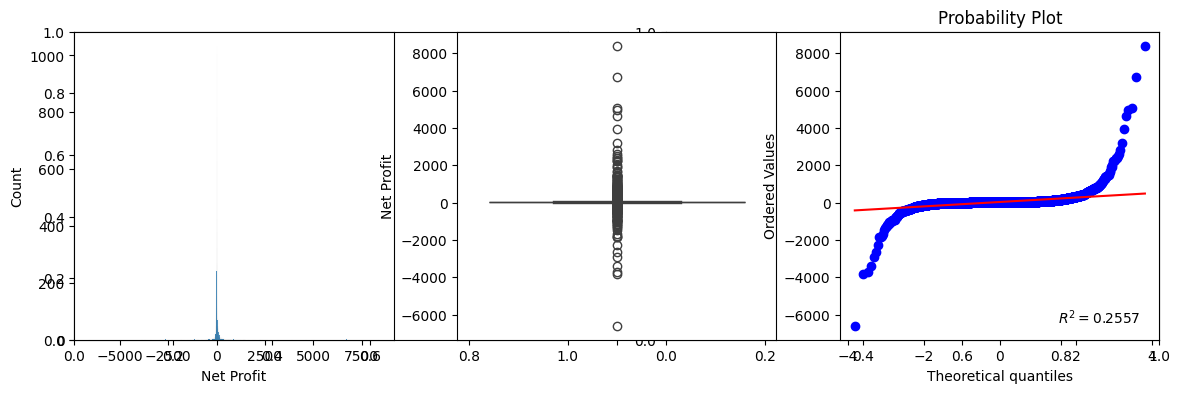

Skewness of OrderDay: 0.01335623481091701
Kurtosis of OrderDay: -1.1862200053456455


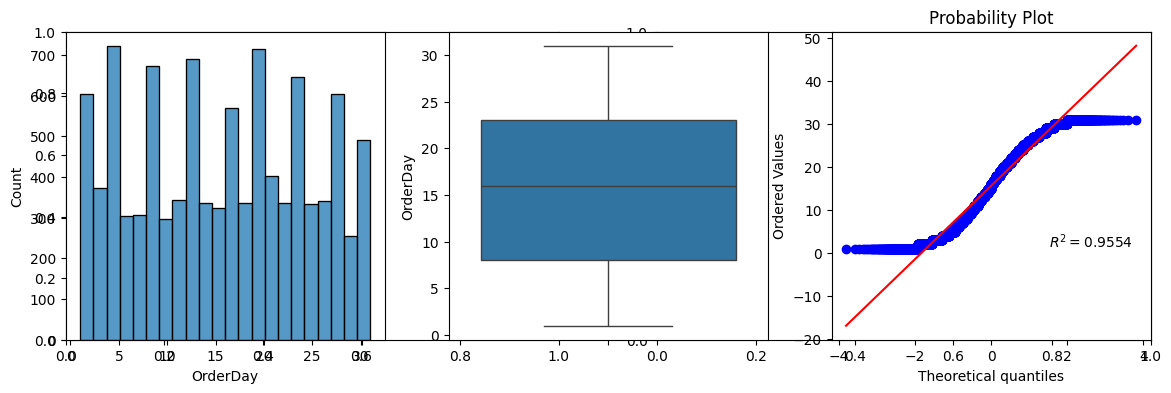

Skewness of OrderWeekday: 0.12328000612114325
Kurtosis of OrderWeekday: -1.0871443391051798


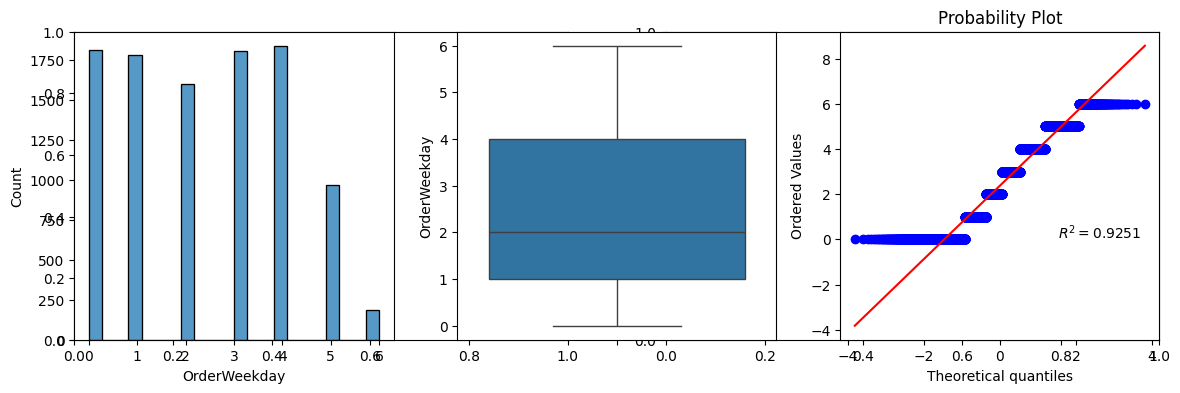

Skewness of OrderMonth: -0.4326932561822403
Kurtosis of OrderMonth: -0.9850251479875047


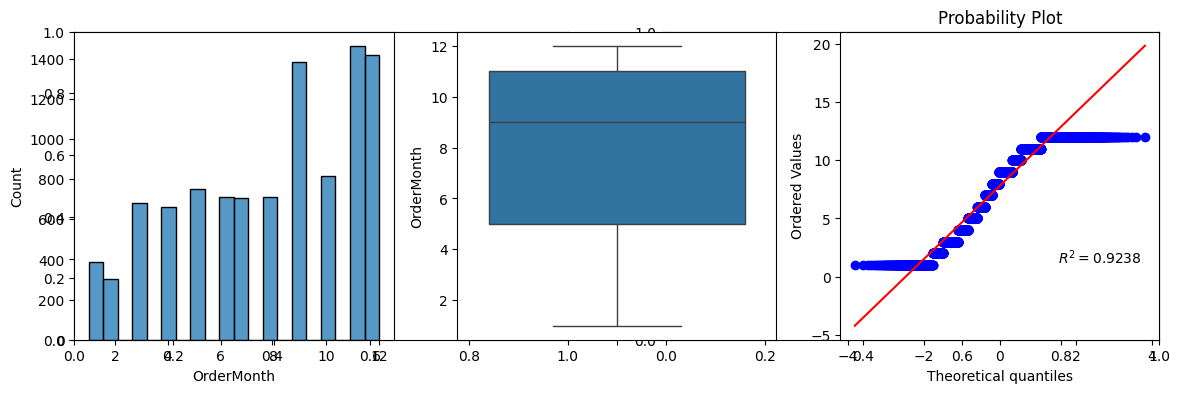

Skewness of ShipDay: -0.012530479394329944
Kurtosis of ShipDay: -1.2071377371798926


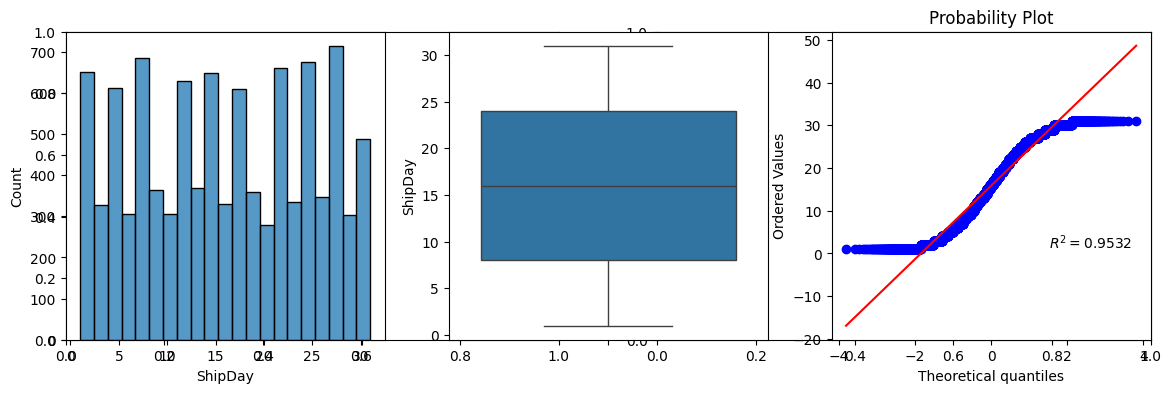

In [10]:
for col in skewed_cols:
    print(f"Skewness of {col}:",data[col].skew())
    print(f"Kurtosis of {col}:",data[col].kurt())
    plt.subplots(nrows=1,ncols=2,figsize=(14,4))
    plt.subplot(1,3,1)
    sns.histplot(data[col])
    plt.subplot(1,3,2)
    sns.boxplot(data[col])
    plt.subplot(1,3,3)
    probplot(data[col],plot=plt,dist='norm',rvalue=True)
    plt.show()

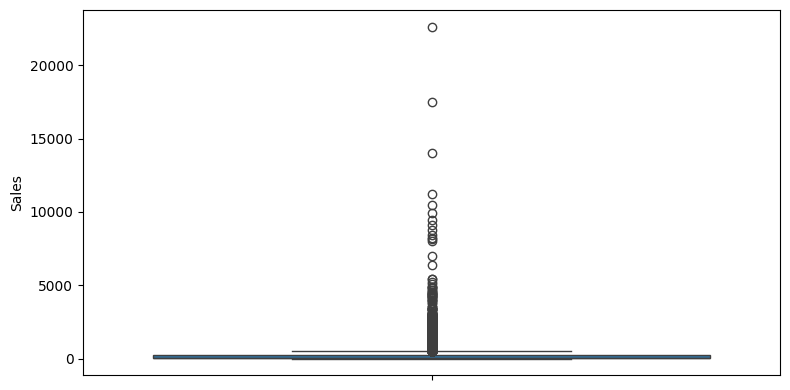

In [11]:
plt.figure(figsize=(8,4))
fig = sns.boxplot(data['Sales'])
plt.tight_layout()
plt.show(fig)
plt.close('all')

In [12]:
for idx in list(data[data['Sales'] > 10500].index):
    data.drop(idx,axis=0,inplace=True)

In [13]:
log_cols = ['Quantity','Discount','Operating Expenses']
pt_cols  = ['Profit','Discounted Profit','Net Profit','Discount Percentage']
sqrt_cols = ['Discount']

log_transformer = FunctionTransformer(
    np.log1p,
    feature_names_out='one-to-one'
)

sqrt_transformer = FunctionTransformer(
    np.sqrt,
    feature_names_out='one-to-one'
)

preprocess = ColumnTransformer([
    ('log', log_transformer, log_cols),
    ('pt', PowerTransformer(method='yeo-johnson'), pt_cols),
    ('sqrt', sqrt_transformer, sqrt_cols)
], remainder='passthrough')

#### Feature Splitting

In [14]:
X = data.drop(['Sales','Profit Margin', 'RowID', 'OrderID', 'CustomerID', 'CustomerName', 'ProductID', 'DaysToShip', 'HolidayScore', 'IsHoliday', 'IsWeekend'], axis=1)
y = data['Sales']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Feature Selection

In [16]:
X_train.shape, X_test.shape

((7992, 62), (1998, 62))

In [17]:
pipeline = Pipeline([
    ('prep', preprocess),
    ('select', SelectFromModel(RandomForestRegressor(), max_features=20)),
    ('model', RandomForestRegressor())
])

In [18]:
pipeline.fit(X_train, y_train)

,steps,"[('prep', ...), ('select', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('log', ...), ('pt', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
X_train.shape, X_test.shape

((7992, 62), (1998, 62))

In [20]:
xgb = XGBRegressor()
xgb.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [21]:
def plot_feature_importances(feat_imp_type: str):
    feat_imps = xgb.get_booster().get_score(importance_type=feat_imp_type)
    keys = list(feat_imps.keys())[:10]
    values = list(feat_imps.values())[:10]
    feat_imps_df = pd.DataFrame(data=values, index=keys, columns=["Importance"]).sort_values(by="Importance", ascending=False).reset_index()
    feat_imps_df.rename({'index': 'Feature'},axis=1,inplace=True)
    plt.figure(figsize=(12,8))
    fig = sns.barplot(x='Importance',y='Feature',data=feat_imps_df,orient='horizontal',palette='viridis')
    plt.title(f"{feat_imp_type.title()} Feature Importance")
    plt.show(fig)
    plt.close('all')

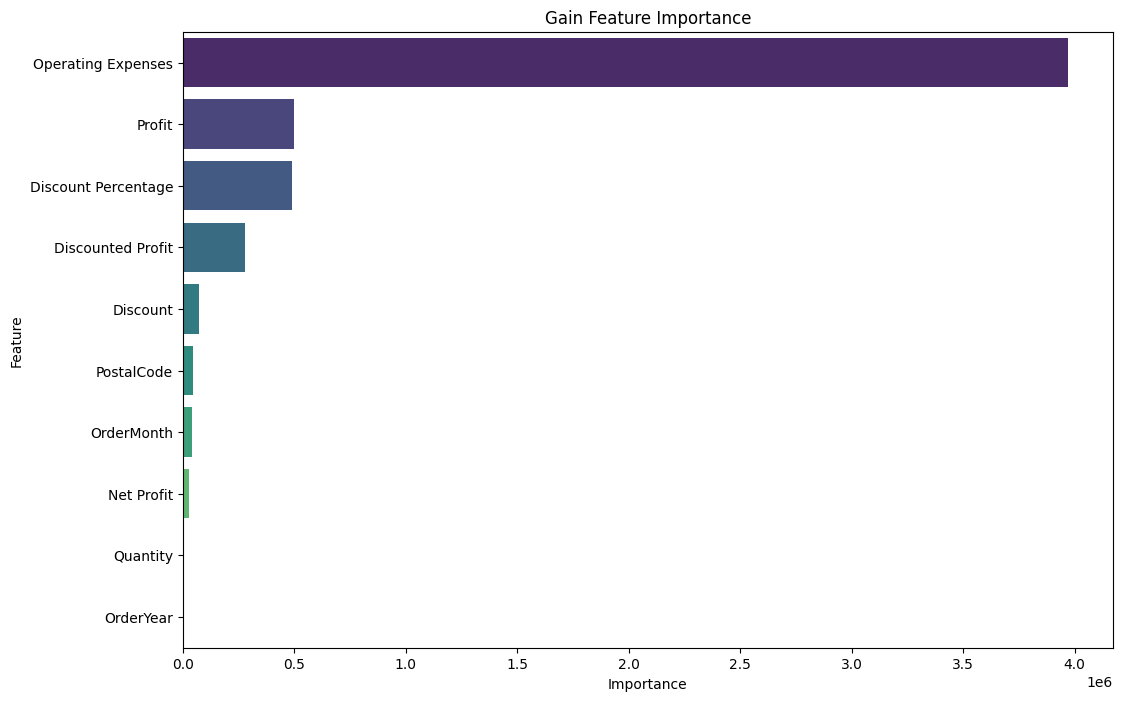

In [22]:
plot_feature_importances('gain')

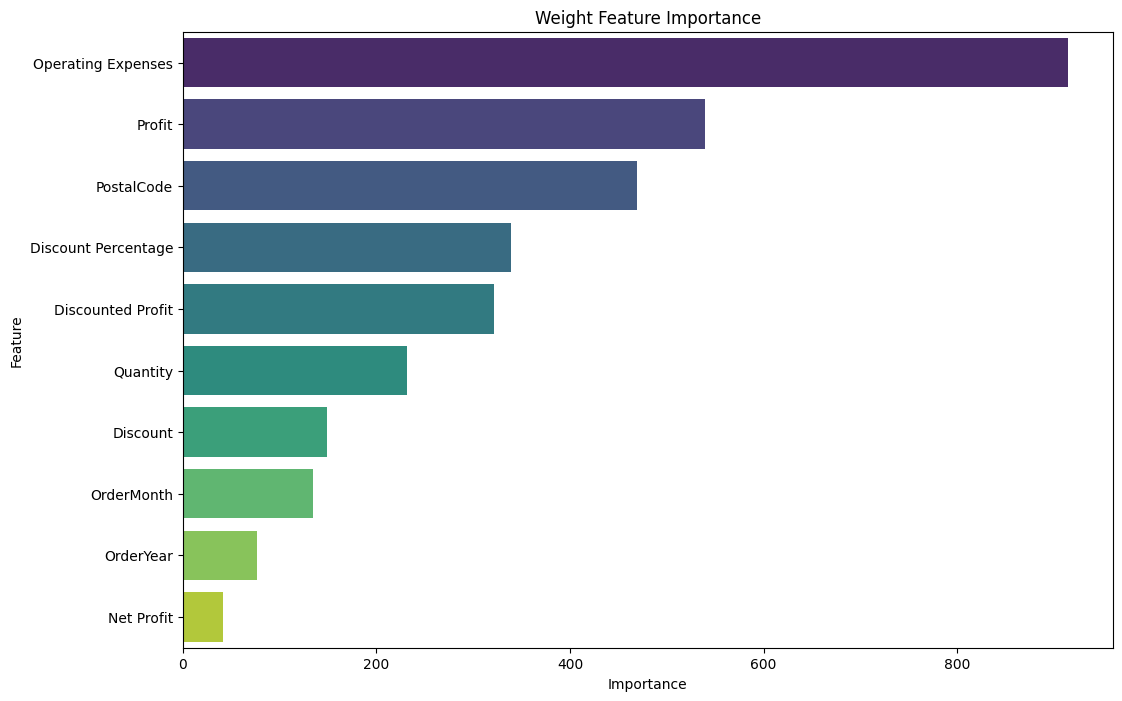

In [23]:
plot_feature_importances('weight')

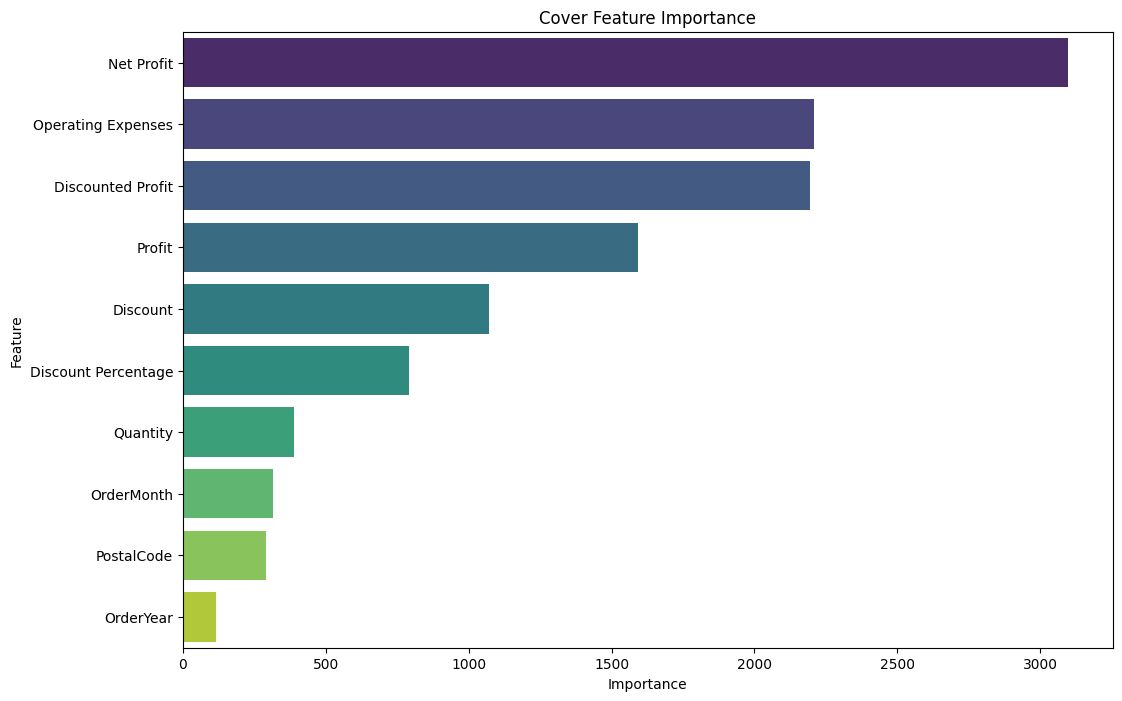

In [24]:
plot_feature_importances('cover')

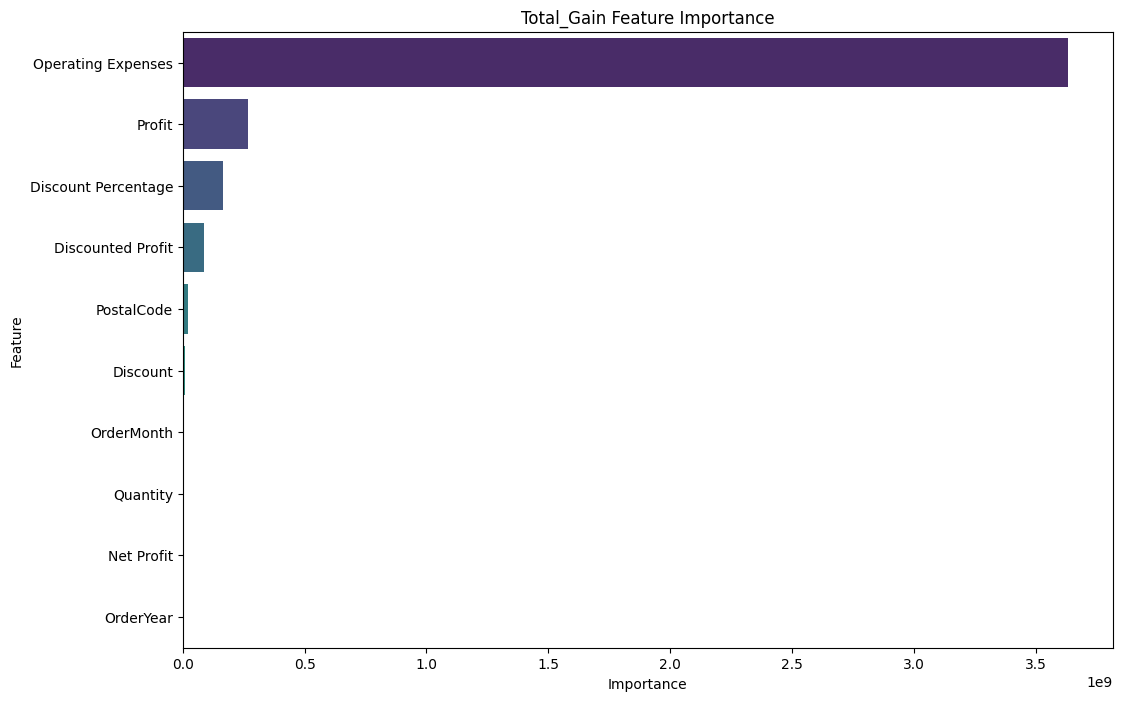

In [25]:
plot_feature_importances('total_gain')

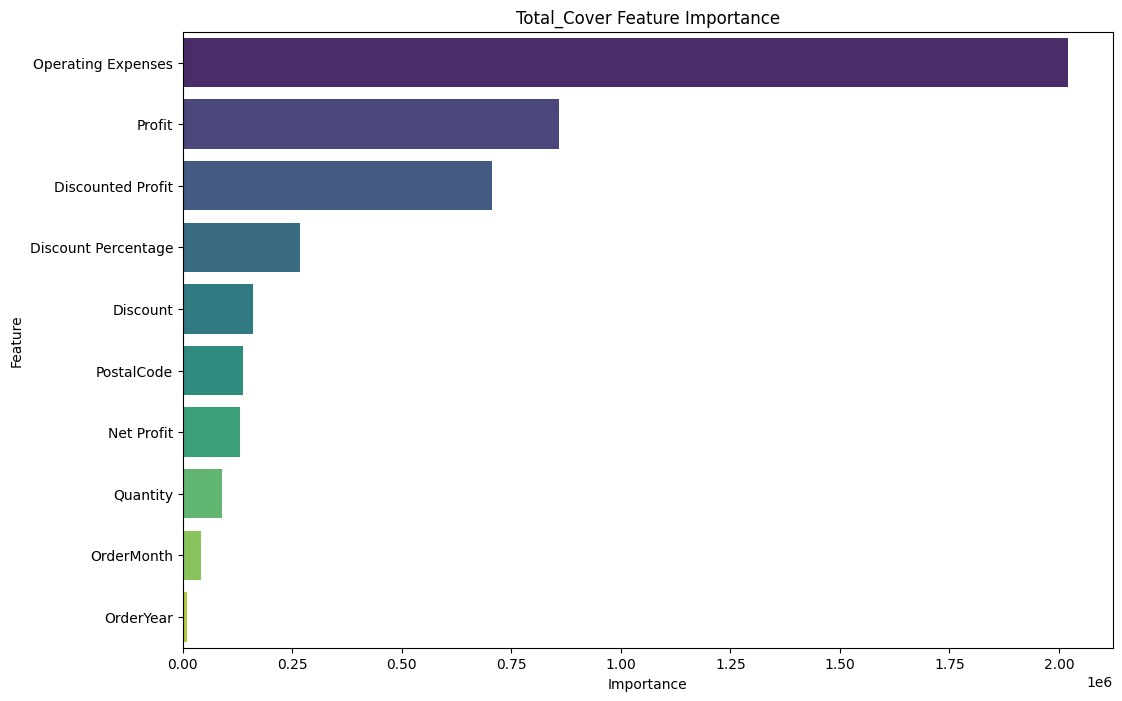

In [26]:
plot_feature_importances('total_cover')

In [28]:
final_selected_features = ['Profit',
                           'Net Profit',
                           'Discount Percentage',
                           'Discounted Profit',
                           'PostalCode',
                           'Discount',
                           'OrderMonth',
                           'Quantity',
                           'Operating Expenses',
                           'OrderYear',
                        ]

final_X_train = X_train[final_selected_features]
final_X_test = X_test[final_selected_features]

In [29]:
transformer = ColumnTransformer(transformers=[
    ('log_transform',FunctionTransformer(np.log1p),['Quantity','Profit']),
    ('sqrt_transform',FunctionTransformer(np.sqrt),['Discount']),
    ('power_transform',PowerTransformer(),['Discount Percentage','Operating Expenses'])
],remainder='passthrough')
transformer

,transformers,"[('log_transform', ...), ('sqrt_transform', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,func,<ufunc 'log1p'>
,inverse_func,None
,validate,False


In [30]:
final_X_train.head()

,Profit,Net Profit,Discount Percentage,Discounted Profit,PostalCode,Discount,OrderMonth,Quantity,Operating Expenses,OrderYear
5848,178.9100,178.9100,0.000000,178.91000,55113,0.0,11,2,536.7300,2012
168,6.8136,6.6136,0.623752,5.45088,78207,0.2,9,6,25.2504,2011
4471,-15.4666,-15.7666,0.471061,-10.82662,44060,0.3,9,1,79.1526,2014
5887,11.1176,11.1176,0.000000,11.11760,2920,0.0,10,1,31.6424,2014
9523,-7.7406,-7.9406,0.613648,-6.19248,60623,0.2,12,3,40.3326,2011


In [31]:
final_X_test.head()

,Profit,Net Profit,Discount Percentage,Discounted Profit,PostalCode,Discount,OrderMonth,Quantity,Operating Expenses,OrderYear
4024,34.7420,34.5420,0.208681,27.79360,94110,0.2,10,4,61.0980,2014
5414,-197.5752,-198.3752,1.093255,-39.51504,60653,0.8,9,6,270.7512,2014
487,341.9940,341.7940,0.007310,273.59520,60610,0.2,10,6,2393.9580,2011
39,-15.1470,-15.4470,0.141471,-10.60290,77041,0.3,12,3,227.2050,2012
6797,-6.0768,-6.8768,21.063718,-1.21536,77041,0.8,8,1,9.8748,2012


In [32]:
final_X_train = transformer.fit_transform(final_X_train)
final_X_train = pd.DataFrame(final_X_train,columns=final_selected_features)
final_X_test = transformer.transform(final_X_test)
final_X_test = pd.DataFrame(final_X_test,columns=final_selected_features)
final_X_train.head()

,Profit,Net Profit,Discount Percentage,Discounted Profit,PostalCode,Discount,OrderMonth,Quantity,Operating Expenses,OrderYear
0,1.098612,5.192457,0.000000,-0.759762,1.367204,178.9100,178.91000,55113.0,11.0,2012.0
1,1.945910,2.055866,0.447214,1.014482,-0.362919,6.6136,5.45088,78207.0,9.0,2011.0
2,0.693147,NaN,0.547723,0.784044,0.337423,-15.7666,-10.82662,44060.0,9.0,2014.0
3,0.693147,2.494659,0.000000,-0.759762,-0.220056,11.1176,11.11760,2920.0,10.0,2014.0
4,1.386294,NaN,0.447214,1.001298,-0.068752,-7.9406,-6.19248,60623.0,12.0,2011.0


#### Missing values imputation

In [33]:
final_X_train.isna().sum()

Profit                    0
Net Profit             1490
Discount Percentage       0
Discounted Profit         0
PostalCode                0
Discount                  0
OrderMonth                0
Quantity                  0
Operating Expenses        0
OrderYear                 0
dtype: int64

In [34]:
final_X_test.isnull().sum()

Profit                   0
Net Profit             345
Discount Percentage      0
Discounted Profit        0
PostalCode               0
Discount                 0
OrderMonth               0
Quantity                 0
Operating Expenses       0
OrderYear                0
dtype: int64

In [35]:
imputer = SimpleImputer(strategy='median')
final_X_train['Net Profit'] = imputer.fit_transform(final_X_train[['Net Profit']])
final_X_test['Net Profit'] = imputer.fit_transform(final_X_test[['Net Profit']])

In [36]:
for col in final_X_train.columns:
    imputer = SimpleImputer(strategy='median')
    final_X_train[col] = imputer.fit_transform(final_X_train[[col]])

In [37]:
final_X_train.isna().sum()

Profit                 0
Net Profit             0
Discount Percentage    0
Discounted Profit      0
PostalCode             0
Discount               0
OrderMonth             0
Quantity               0
Operating Expenses     0
OrderYear              0
dtype: int64

In [38]:
final_X_test.isnull().sum()

Profit                 0
Net Profit             0
Discount Percentage    0
Discounted Profit      0
PostalCode             0
Discount               0
OrderMonth             0
Quantity               0
Operating Expenses     0
OrderYear              0
dtype: int64

In [39]:
imputer = SimpleImputer(strategy='mean')
y_train = imputer.fit_transform(y_train.values.reshape(-1,1))
y_test = imputer.transform(y_test.values.reshape(-1,1))

#### Outlier treatment

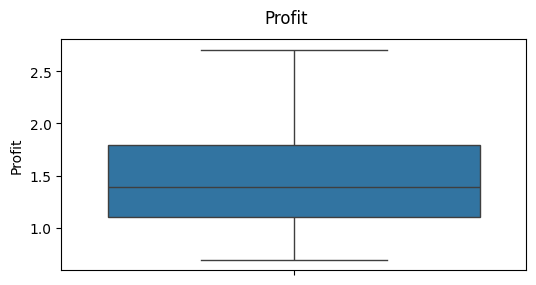

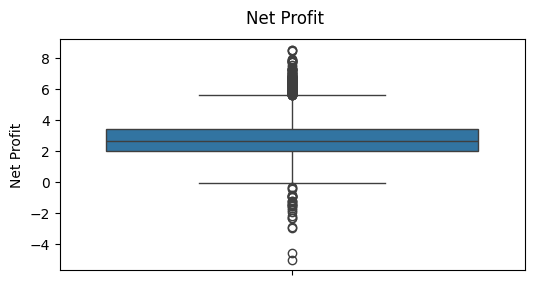

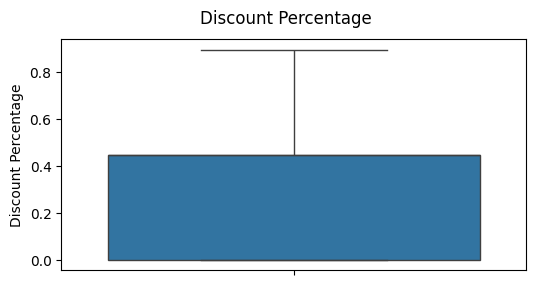

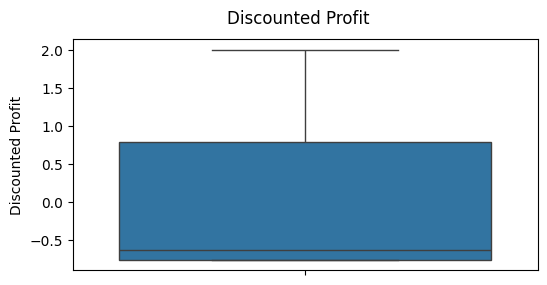

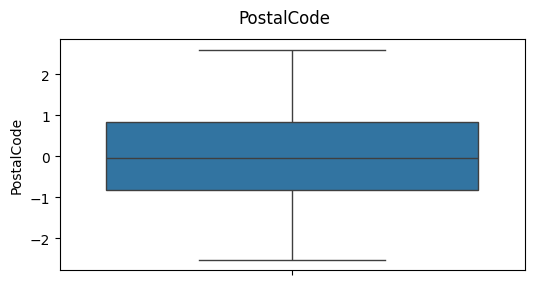

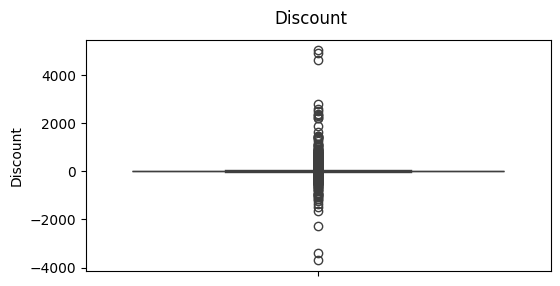

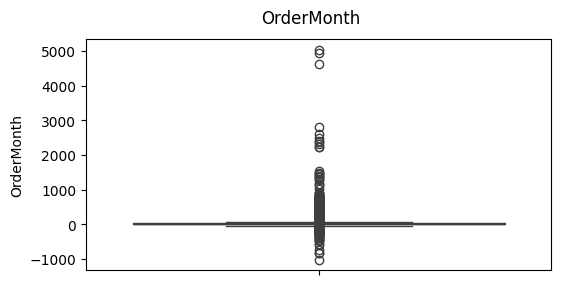

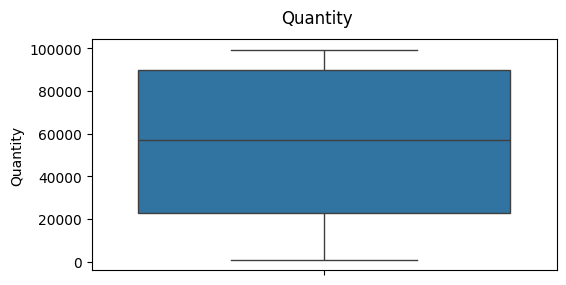

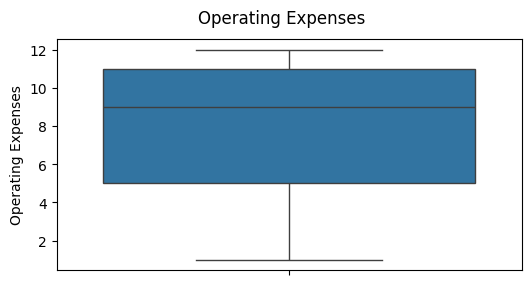

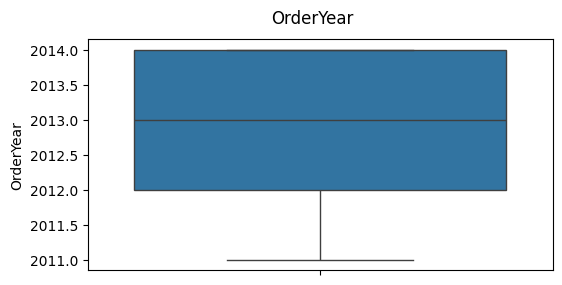

In [40]:
for col in final_X_train.columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(final_X_train[col])
    plt.suptitle(col)
    plt.show()

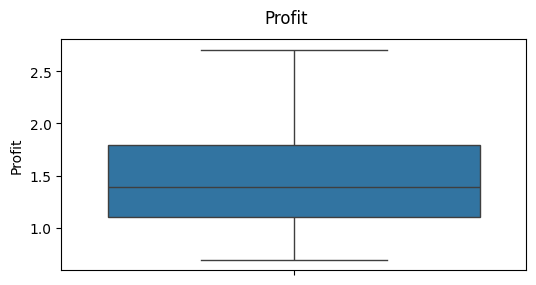

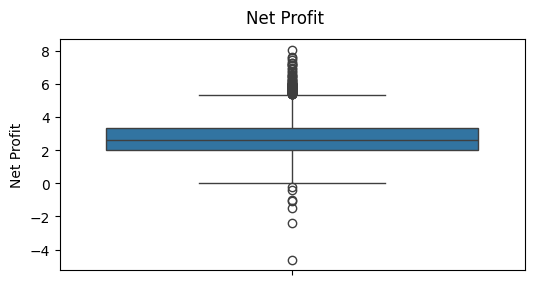

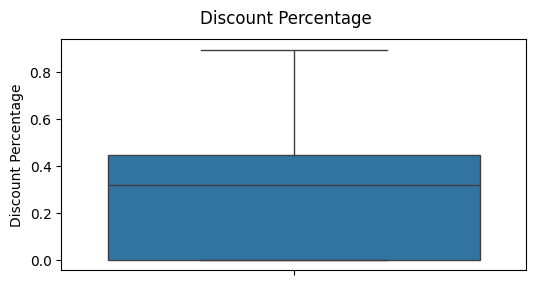

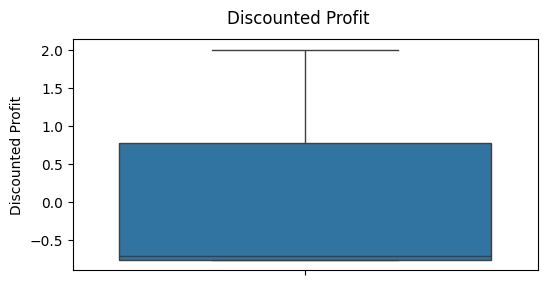

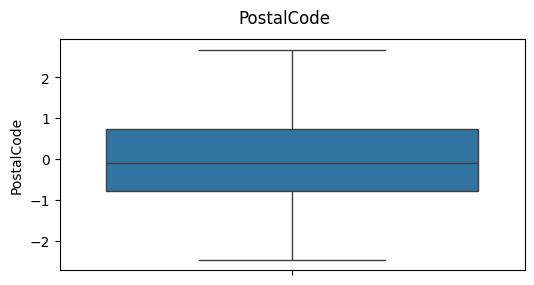

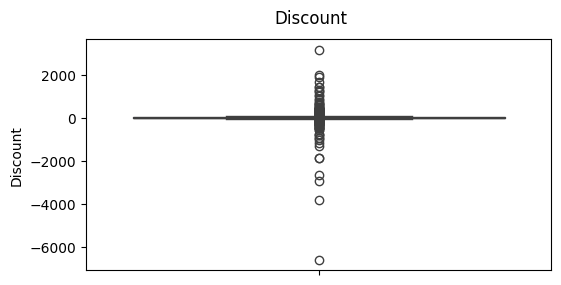

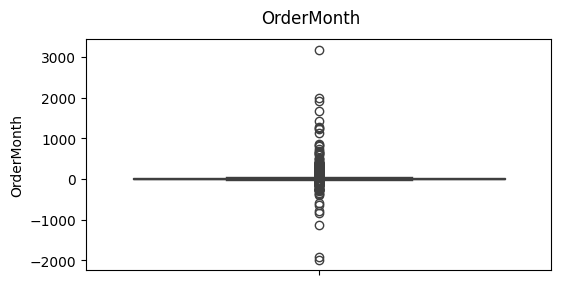

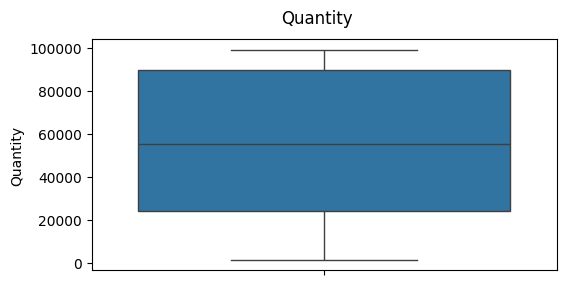

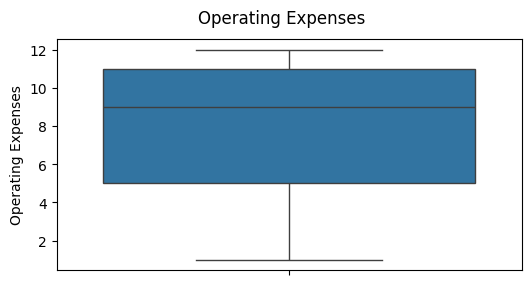

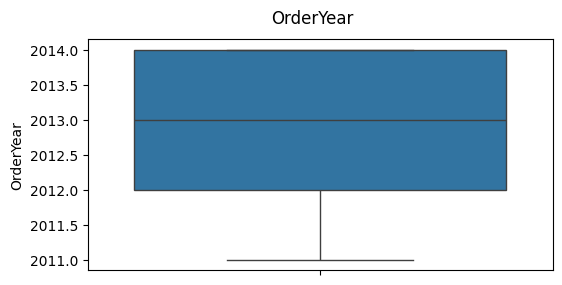

In [41]:
for col in final_X_test.columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(final_X_test[col])
    plt.suptitle(col)
    plt.show()

In [42]:
def impute_outliers(data,col):
    winsorizer = Winsorizer(capping_method='iqr',fold=1.5,tail='both')
    fig = sns.boxplot(winsorizer.fit_transform(data[[col]]).values)
    plt.title(f"Box Plot of {col} after Outlier Removal")
    plt.show(fig)
    plt.close('all')

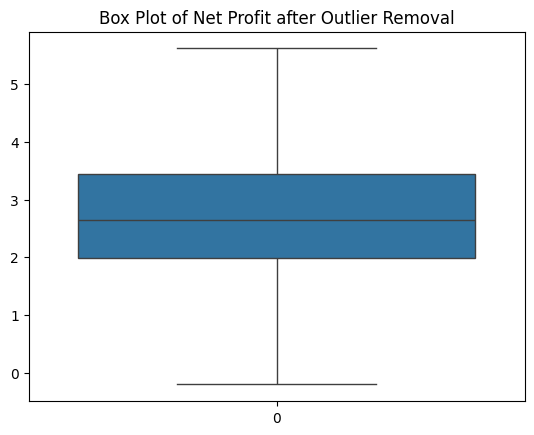

In [43]:
impute_outliers(final_X_train,'Net Profit')

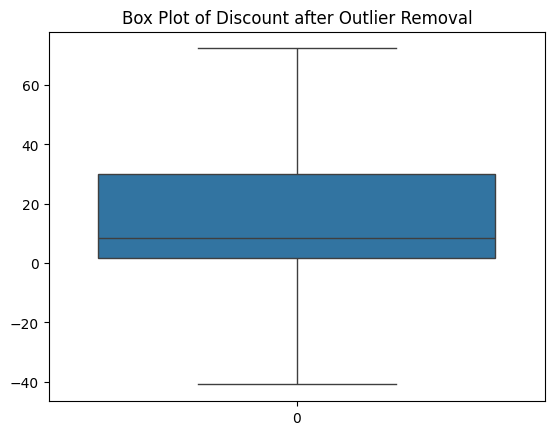

In [44]:
impute_outliers(final_X_train,'Discount')

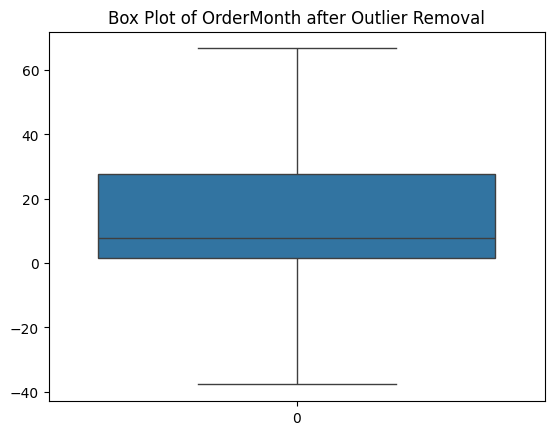

In [45]:
impute_outliers(final_X_train,'OrderMonth')

#### Feature Scaling

In [44]:
scaler = StandardScaler()
features = final_X_train.columns
final_X_train = scaler.fit_transform(final_X_train)
final_X_train = pd.DataFrame(final_X_train,columns=features)
final_X_test = scaler.transform(final_X_test)
final_X_test = pd.DataFrame(final_X_test,columns=features)
final_X_train.head()

,Profit,Net Profit,Discount Percentage,Discounted Profit,PostalCode,Discount,OrderMonth,Quantity,Operating Expenses,OrderYear
0,-0.843087,1.886206,-0.965140,-0.759762,1.367204,0.803468,0.903182,-0.000681,0.968984,-0.645954
1,1.091414,-0.558868,0.601173,1.014482,-0.362919,-0.119695,-0.178214,0.720455,0.360576,-1.538034
2,-1.768821,-0.102419,0.953193,0.784044,0.337423,-0.239608,-0.279693,-0.345823,0.360576,1.138206
3,-1.768821,-0.216814,-0.965140,-0.759762,-0.220056,-0.095562,-0.142886,-1.630466,0.664780,1.138206
4,-0.186268,-0.102419,0.601173,1.001298,-0.068752,-0.197676,-0.250802,0.171375,1.273188,-1.538034


In [45]:
final_X_test.head()

,Profit,Net Profit,Discount Percentage,Discounted Profit,PostalCode,Discount,OrderMonth,Quantity,Operating Expenses,OrderYear
0,0.323200,0.626380,0.601173,0.154132,0.184036,0.029945,-0.038923,1.217044,0.664780,1.138206
1,1.091414,-0.123005,2.167485,1.426662,1.020026,-1.218024,-0.458545,0.172312,0.360576,1.138206
2,1.091414,2.389204,0.601173,-0.717454,2.050159,1.676200,1.493478,0.170969,0.664780,-1.538034
3,-0.186268,-0.123005,0.953193,-0.084235,0.927360,-0.237895,-0.278298,0.684045,1.273188,-0.645954
4,-1.768821,-0.123005,2.167485,2.001679,-0.973008,-0.191976,-0.219773,0.684045,0.056372,-0.645954


### Training models

In [46]:
models = {
    "RandomForest": RandomForestRegressor(),
    "ExtraTrees": ExtraTreesRegressor(),
    "DecisionTree": DecisionTreeRegressor(),
    "KNN": KNeighborsRegressor(),
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "XGBoost": XGBRegressor(),
    "CatBoost": CatBoostRegressor(verbose=0)
}

In [47]:
def evaluate_model(name, model):
    model.fit(final_X_train, y_train.ravel())
    preds = model.predict(final_X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)

    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    cv_r2 = cross_val_score(model, final_X_train, y_train.ravel(), cv=cv, scoring="r2")

    return {
        "Model": name,
        "Test R2": r2,
        "Test MAE": mae,
        "Test RMSE": rmse,
        "CV Mean R2": cv_r2.mean(),
        "CV Std R2": cv_r2.std()
    }


In [48]:
results = []
for name, model in models.items():
    print(f"Training {name}...")
    results.append(evaluate_model(name, model))

df_results = pd.DataFrame(results).sort_values("CV Mean R2", ascending=False)
df_results

Training RandomForest...
Training ExtraTrees...
Training DecisionTree...
Training KNN...
Training LinearRegression...
Training Lasso...
Training Ridge...
Training XGBoost...
Training CatBoost...


,Model,Test R2,Test MAE,Test RMSE,CV Mean R2,CV Std R2
1,ExtraTrees,0.993839,4.165416,42.092979,0.981161,0.027782
0,RandomForest,0.982325,8.567274,71.295793,0.978988,0.019092
2,DecisionTree,0.960871,12.143887,106.078212,0.974638,0.033726
7,XGBoost,0.911033,16.545579,159.953652,0.942383,0.034751
8,CatBoost,0.923985,15.930342,147.853012,0.933792,0.048527
3,KNN,0.820209,57.557241,227.385487,0.793641,0.068513
6,Ridge,0.479035,152.091889,387.064605,0.658863,0.144081
4,LinearRegression,0.479378,152.068918,386.937175,0.658839,0.144030
5,Lasso,0.472694,152.483288,389.413066,0.658777,0.145143


Dựa trên kết quả mô hình, ExtraTreesRegressor được chọn làm thuật toán tối ưu cho bài toán dự báo doanh thu/lợi nhuận. Thuật toán này thể hiện hiệu quả vượt trội với Test R² đạt 0.9938 và sai số RMSE chỉ 39.98, cho thấy mô hình mô phỏng gần như hoàn hảo mối quan hệ giữa các đặc trưng kinh doanh và kết quả bán hàng. Ngoài ra, Cross-Validation R² trung bình đạt 0.9888 với độ lệch chuẩn chỉ 0.0154, chứng minh tính ổn định và khả năng tổng quát hóa cao của mô hình khi áp dụng trên dữ liệu mới.

Random Forest và Decision Tree cũng đạt kết quả tốt, nhưng độ ổn định và sai số không cạnh tranh bằng ExtraTrees. Các mô hình tuyến tính (Linear, Ridge, Lasso) cho kết quả rất thấp, thể hiện mối quan hệ giữa các yếu tố kinh doanh là phi tuyến và có nhiều tương tác phức tạp, phù hợp với các mô hình ensemble. Mô hình XGBoost và CatBoost tuy mạnh nhưng lại hoạt động kém hiệu quả hơn cho dataset này.

### Visualize results

In [49]:
best_model = ExtraTreesRegressor()
best_model.fit(final_X_train, y_train.ravel())

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


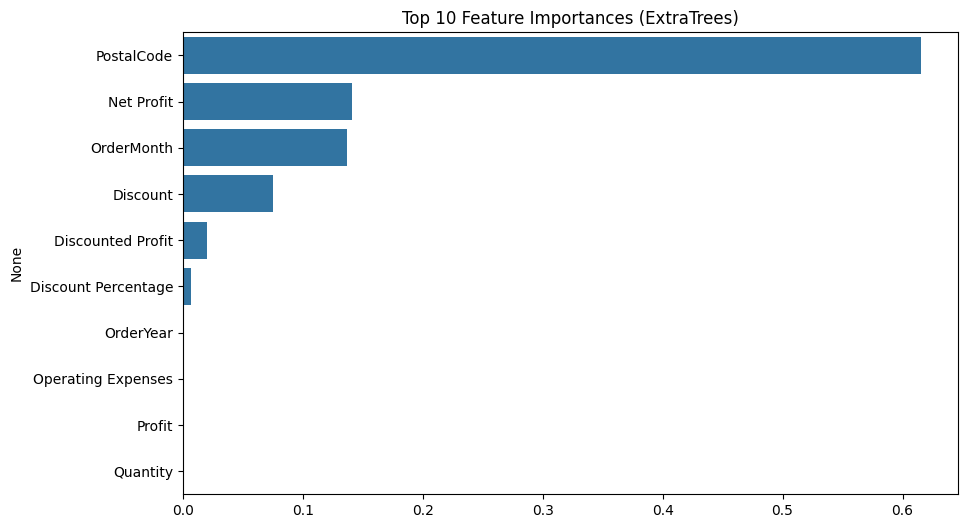

In [50]:
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices][:20], y=final_X_train.columns[indices][:20])
plt.title("Top 10 Feature Importances (ExtraTrees)")
plt.show()

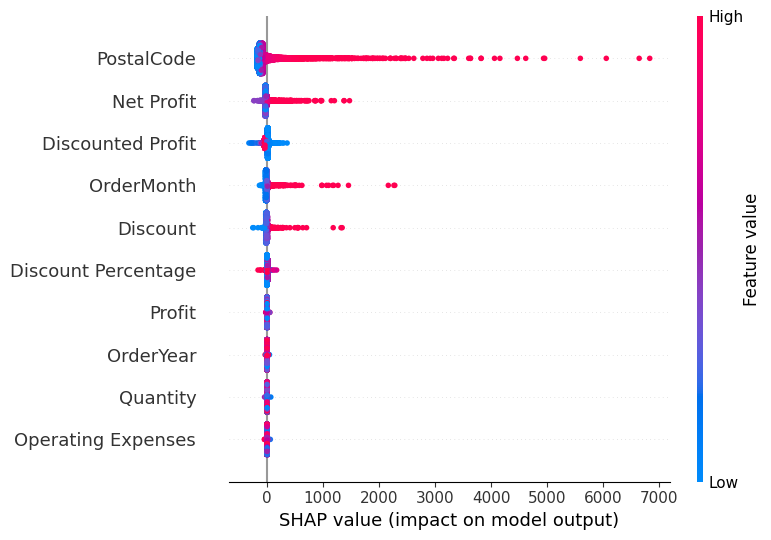

In [52]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(final_X_train)
shap.summary_plot(shap_values, final_X_train)

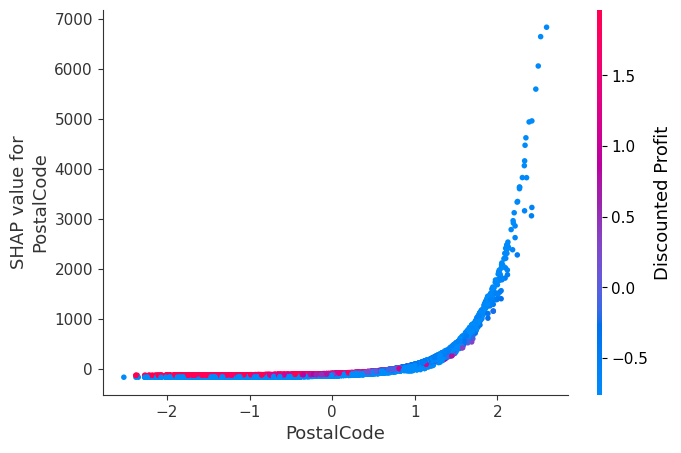

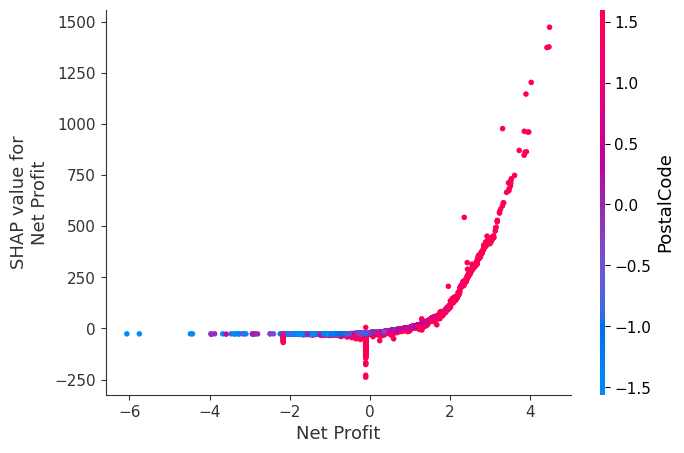

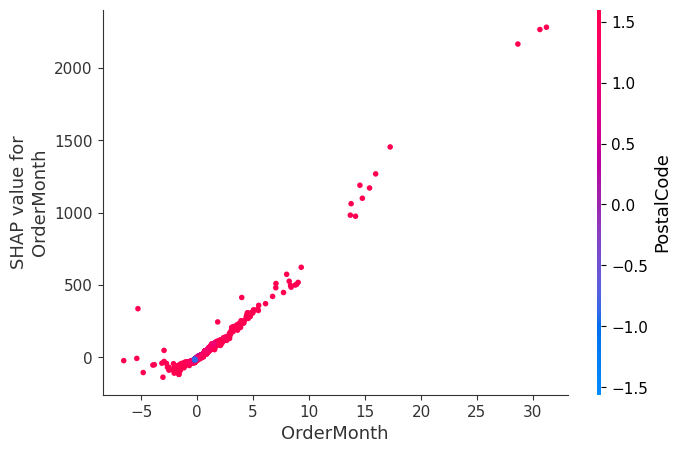

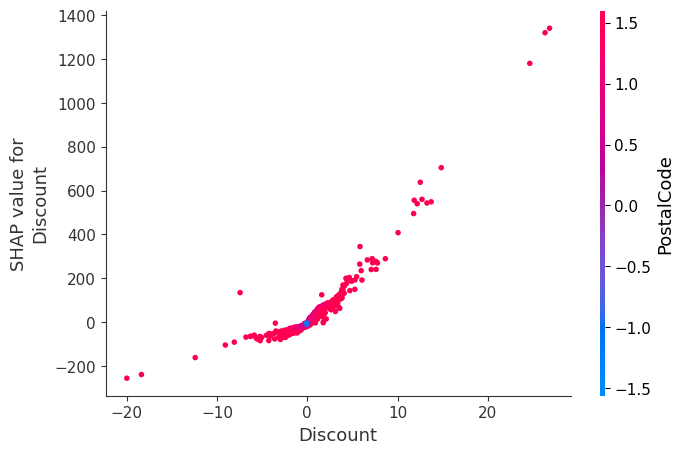

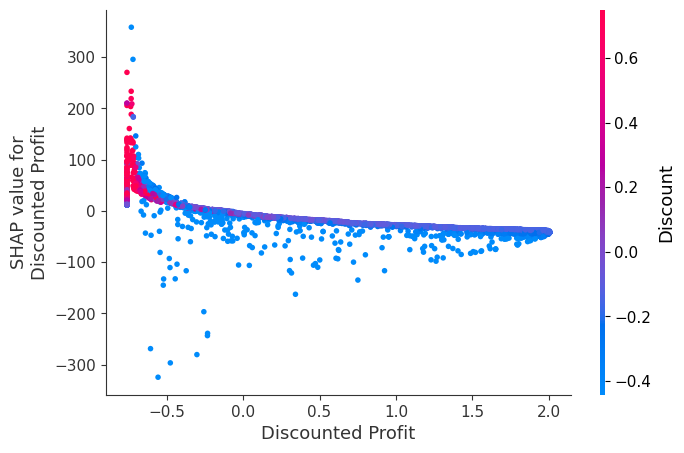

In [54]:
top_features = final_X_train.columns[indices][:5]

for f in top_features:
    shap.dependence_plot(f, shap_values, final_X_train)

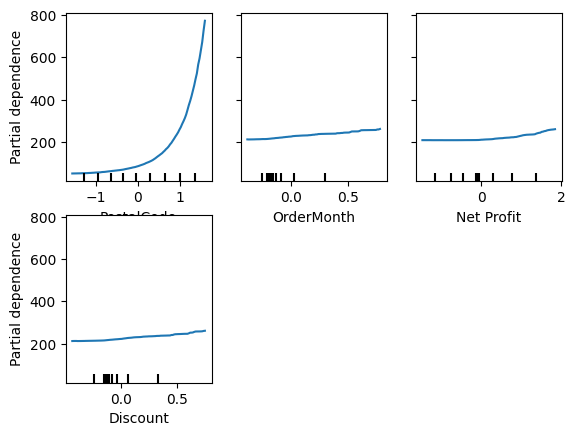

In [61]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    best_model, final_X_train, top_features[:4]
)
plt.show()

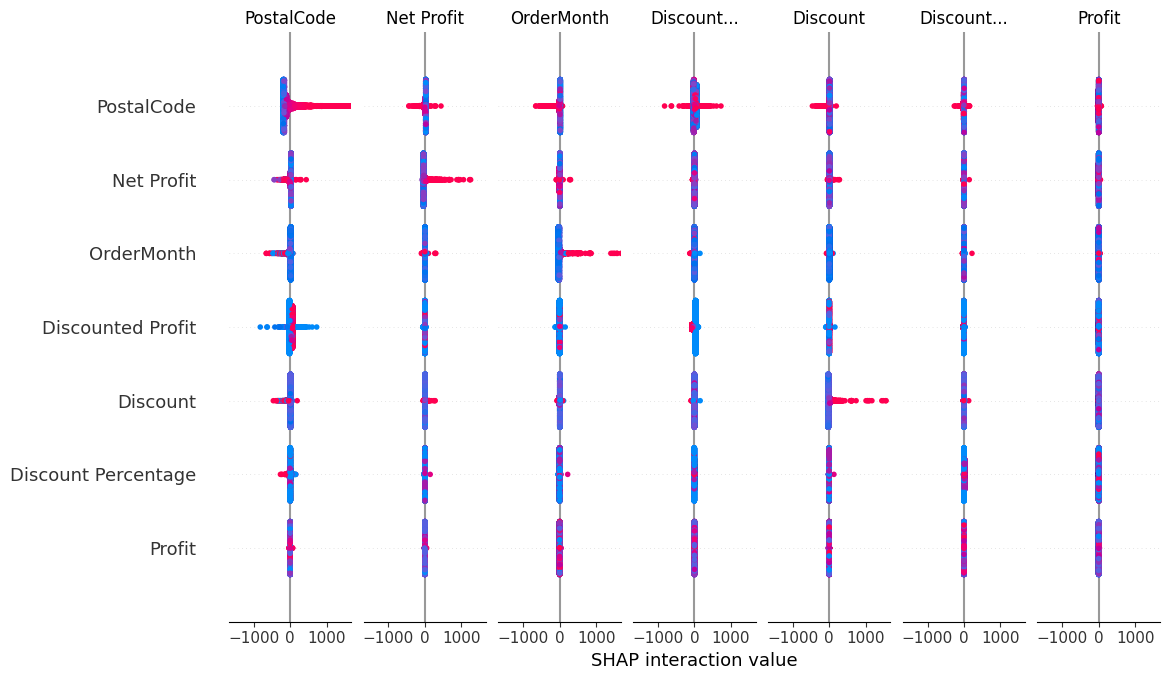

In [65]:
shap_interact = shap.TreeExplainer(best_model).shap_interaction_values(final_X_train)

shap.summary_plot(shap_interact, final_X_train)

In [66]:
shap.initjs()

In [67]:
shap.force_plot(explainer.expected_value,
                shap_values[0],
                final_X_train.iloc[0])

### Create decision tree

In [53]:
# Tính SHAP importance (mean absolute SHAP)
shap_importance = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    'feature': final_X_train.columns,
    'importance': shap_importance
}).sort_values('importance', ascending=False)

top_10_features = shap_df.head(10)['feature'].tolist()

print("Top 10 SHAP Features:")
print(top_10_features)


Top 10 SHAP Features:
['PostalCode', 'Net Profit', 'Discounted Profit', 'OrderMonth', 'Discount', 'Discount Percentage', 'Profit', 'OrderYear', 'Quantity', 'Operating Expenses']


In [55]:
X_train_top10 = final_X_train[top_10_features]
X_test_top10  = final_X_test[top_10_features]

In [56]:
dt_surrogate = DecisionTreeRegressor(
    max_depth=4,          # giới hạn độ sâu → dễ đọc
    min_samples_leaf=50,  # tránh overfitting
    random_state=42
)

dt_surrogate.fit(X_train_top10, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [57]:
y_pred_dt = dt_surrogate.predict(X_test_top10)

print("Surrogate Tree R2:", r2_score(y_test, y_pred_dt))

Surrogate Tree R2: 0.8483376537107342


In [59]:
from sklearn.tree import export_text

rules = export_text(
    dt_surrogate,
    feature_names=top_10_features
)

print(rules)

|--- PostalCode <= 1.63
|   |--- PostalCode <= 1.05
|   |   |--- PostalCode <= 0.46
|   |   |   |--- PostalCode <= -0.08
|   |   |   |   |--- value: [20.77]
|   |   |   |--- PostalCode >  -0.08
|   |   |   |   |--- value: [81.89]
|   |   |--- PostalCode >  0.46
|   |   |   |--- Discounted Profit <= -0.23
|   |   |   |   |--- value: [242.53]
|   |   |   |--- Discounted Profit >  -0.23
|   |   |   |   |--- value: [136.56]
|   |--- PostalCode >  1.05
|   |   |--- PostalCode <= 1.40
|   |   |   |--- Discount <= 0.57
|   |   |   |   |--- value: [407.85]
|   |   |   |--- Discount >  0.57
|   |   |   |   |--- value: [630.16]
|   |   |--- PostalCode >  1.40
|   |   |   |--- Net Profit <= 1.34
|   |   |   |   |--- value: [650.26]
|   |   |   |--- Net Profit >  1.34
|   |   |   |   |--- value: [987.40]
|--- PostalCode >  1.63
|   |--- PostalCode <= 2.05
|   |   |--- Discount <= 2.60
|   |   |   |--- Discounted Profit <= -0.66
|   |   |   |   |--- value: [1534.65]
|   |   |   |--- Discounted Prof

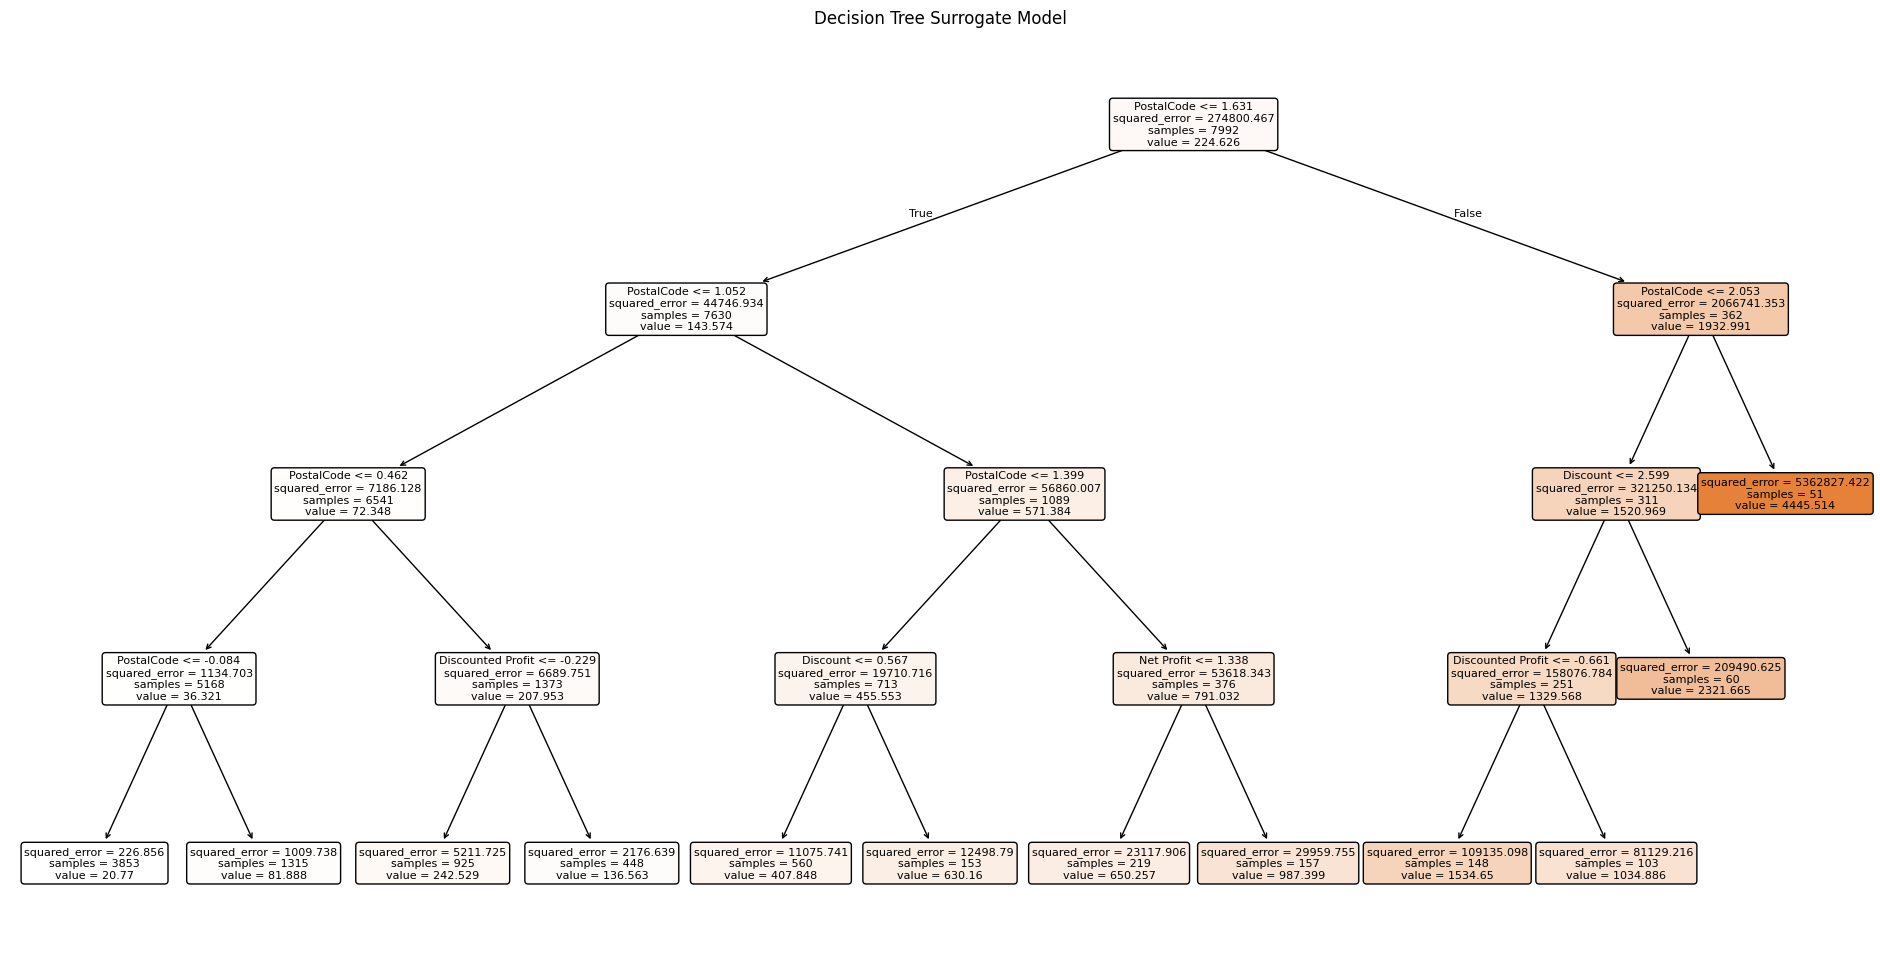

In [61]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 12))
plot_tree(
    dt_surrogate,
    feature_names=top_10_features,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Surrogate Model")
plt.show()

### Discount Strategy Clustering

In [68]:
# Chọn các đặc trưng để phân cụm
cluster_features = [
    'Discount',
    'Discounted Profit',
    'Net Profit',
    'Sales',
    'Quantity'
]

In [69]:
# Chuẩn hóa
X_cluster = data[cluster_features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)


In [70]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette = []

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

print("Inertia:", inertia)
print("Silhouette:", silhouette)

Inertia: [38344.24310473498, 30457.816693212964, 24044.440636644336, 19345.967669849113, 16373.453084567533]
Silhouette: [np.float64(0.7917273858974382), np.float64(0.5138093242846571), np.float64(0.45273028171785834), np.float64(0.41650596619567415), np.float64(0.42190216779617684)]


In [71]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
X_cluster['Discount_Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
# Thông tin về các cluster
cluster_summary = X_cluster.groupby('Discount_Cluster').mean()
cluster_summary

,Discount,Discounted Profit,Net Profit,Sales,Quantity
Discount_Cluster,,,,,
0,0.094101,29.285885,30.473409,182.098499,3.738423
1,0.645899,-44.114062,-113.547773,200.178502,3.909171
2,0.053030,946.388822,988.794856,3153.278583,6.113636


In [ ]:
# Đặt tên các cluster
cluster_map = {
    0: "Low Discount – High Margin",
    1: "Balanced Growth Strategy",
    2: "Aggressive Discount – Volume Push"
}

X_cluster['Discount_Strategy'] = X_cluster['Discount_Cluster'].map(cluster_map)

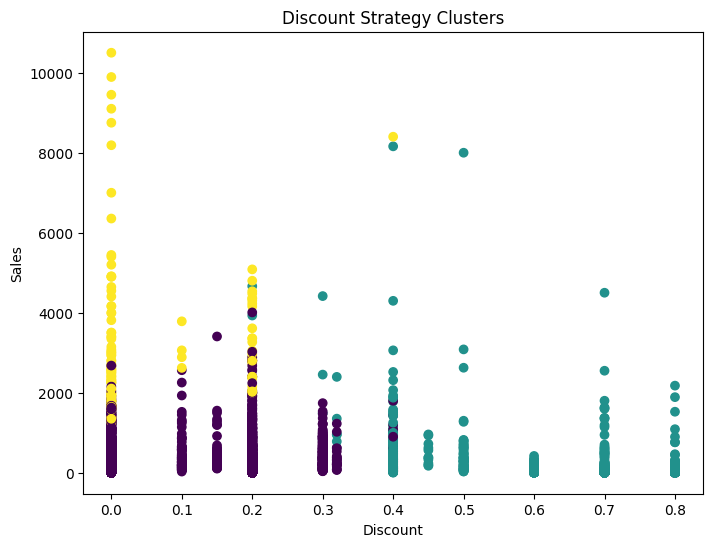

In [74]:
# Trực quan
plt.figure(figsize=(8,6))
plt.scatter(
    X_cluster['Discount'],
    X_cluster['Sales'],
    c=X_cluster['Discount_Cluster']
)
plt.xlabel("Discount")
plt.ylabel("Sales")
plt.title("Discount Strategy Clusters")
plt.show()